# Block 04a - probabilistic nowcasts

STEPS with the session's settings (nonparametric noise, CDF probability matching,
incremental masking, no velocity perturbation), 12 members, and LINDA-P; ensemble mean,
members, exceedance probability for 1 mm/h, and the ensemble scores: CRPS, ROC, reliability
diagram and rank histogram. One issue time here; the study pools them over all events.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import viz_style as vs
from os_nowcasting import data, grid, nowcast, plots, products, verify
vs.use_style()

In [2]:
NET, STEP = "openrainer", 15
radar = data.radar(NET, "2022-08-18 05:45", "2022-08-18 11:00")
rate, meta = grid.to_pysteps(radar, STEP)
times = pd.DatetimeIndex(radar.time.values)
ISSUE = times.get_loc(pd.Timestamp("2022-08-18 08:45"))
print(rate.shape, "pixels of", meta["xpixelsize"] / 1000, "km; issue time", times[ISSUE])

(22, 97, 155) pixels of 2.0000659081611216 km; issue time 2022-08-18 08:45:00


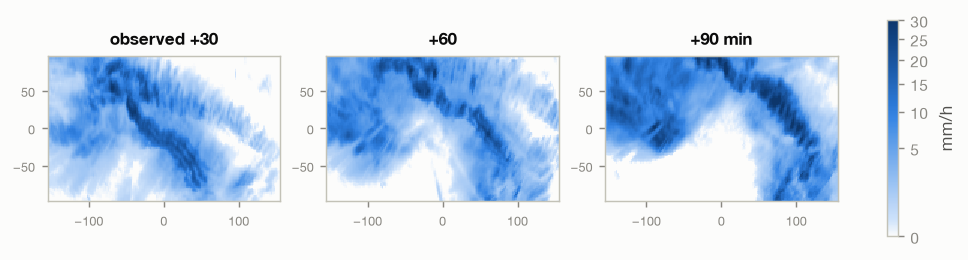

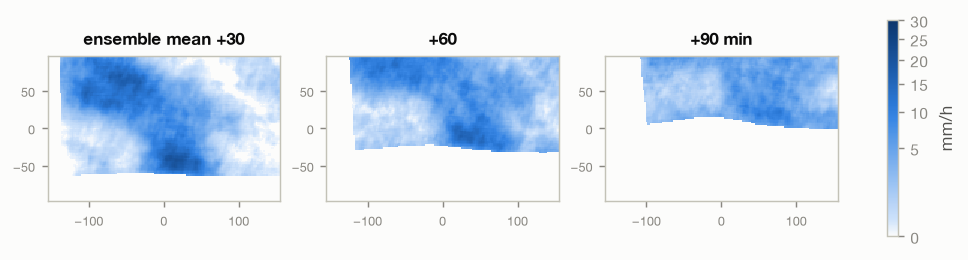

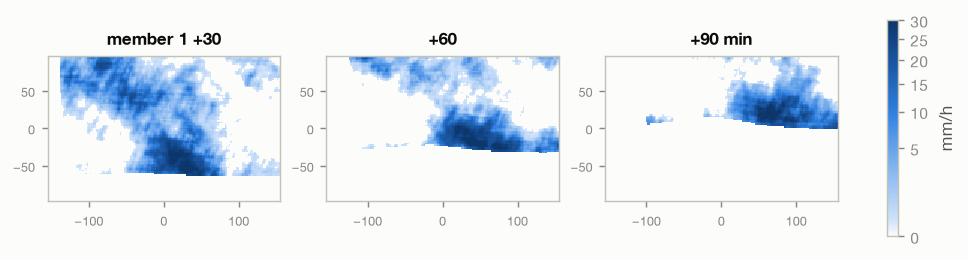

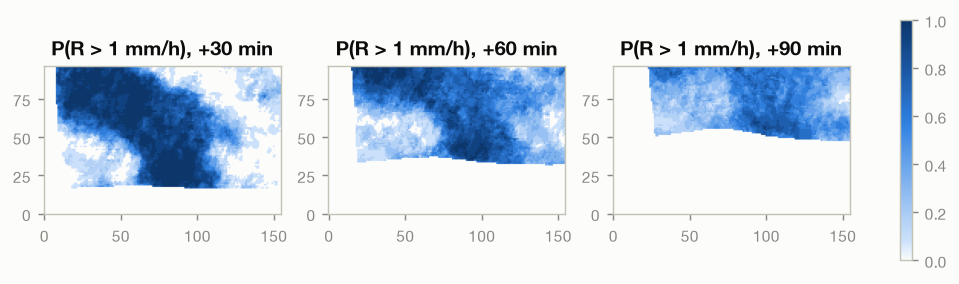

In [3]:
N, M = 6, 12
past, obs = rate[:ISSUE + 1], rate[ISSUE + 1:ISSUE + 1 + N]
v = nowcast.motion(past, meta, "LK")
E = nowcast.ensemble("steps", past, meta, v, N, n_members=M)
fig, axes = plots.row(list(obs[[1, 3, 5]]), ["observed +30", "+60", "+90 min"], meta, vmax=30)
fig, axes = plots.row(list(E.mean(0)[[1, 3, 5]]), ["ensemble mean +30", "+60", "+90 min"], meta, vmax=30)
fig, axes = plots.row(list(E[0][[1, 3, 5]]), ["member 1 +30", "+60", "+90 min"], meta, vmax=30)
P = (E >= 1.0).mean(0)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, k in zip(axes, [1, 3, 5]):
    im = ax.imshow(P[k], origin="lower", cmap=vs.CMAP_RAIN, vmin=0, vmax=1)
    ax.set_title(f"P(R > 1 mm/h), +{15 * (k + 1)} min"); ax.grid(False)
fig.colorbar(im, ax=axes.tolist(), shrink=0.8);

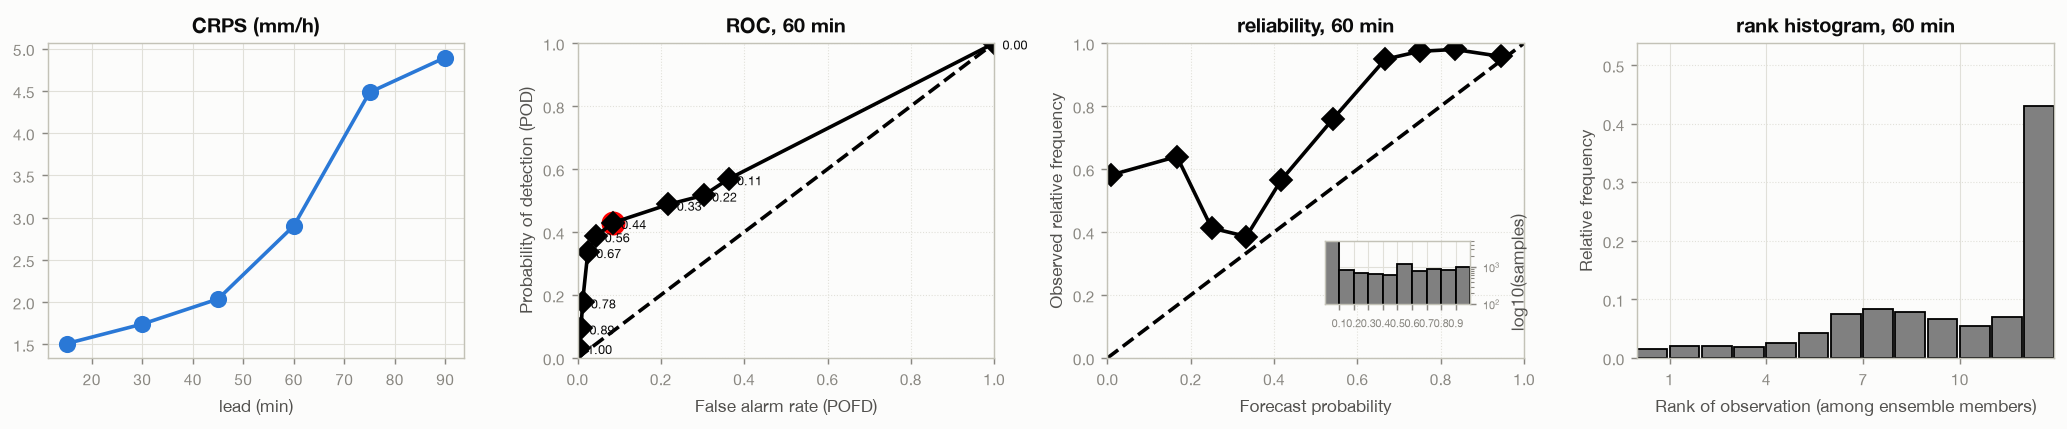

In [4]:
from pysteps import verification as pv
crps = [pv.probscores.CRPS(E[:, k], obs[k]) for k in range(N)]
roc = pv.ROC_curve_init(1.0, n_prob_thrs=10); pv.ROC_curve_accum(roc, P[3], obs[3])
rel = pv.reldiag_init(1.0); pv.reldiag_accum(rel, P[3], obs[3])
rank = pv.rankhist_init(M, 0.1); pv.rankhist_accum(rank, E[:, 3], obs[3])
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
axes[0].plot(15 * np.arange(1, N + 1), crps, marker="o", color="#2a78d6"); axes[0].set_title("CRPS (mm/h)"); axes[0].set_xlabel("lead (min)")
pv.plot_ROC(roc, axes[1], opt_prob_thr=True); axes[1].set_title("ROC, 60 min")
pv.plot_reldiag(rel, axes[2]); axes[2].set_title("reliability, 60 min")
pv.plot_rankhist(rank, axes[3]); axes[3].set_title("rank histogram, 60 min")
fig.tight_layout()

In [5]:
EL = nowcast.ensemble("linda_p", past, meta, v, N, n_members=M)
print("CRPS at 60 min: STEPS", round(crps[3], 3), " LINDA-P", round(pv.probscores.CRPS(EL[:, 3], obs[3]), 3))

CRPS at 60 min: STEPS 2.902  LINDA-P 3.198
